In [1]:
from topological_insulator import Problem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [3]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC, t_1, delta):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.01 * t_1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                if label_i != "C":
                    parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1 - delta
                    parser["nn_hopping"][label_j]["t_pp_pi"] = t_1 + delta
                else:
                    parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1
                    parser["nn_hopping"][label_j]["t_pp_pi"] = t_1
            except:
                pass
        # print(parser)   

In [4]:
location = "bulk"

In [5]:
deltas = np.linspace(-2, 2, 40)

In [ ]:
t_1 = -1
Delta_SOC = -5
results = []
problems = {}
for n, delta in enumerate(deltas):
    print("")
    print(f"Running case for: delta/t_1 = {delta/t_1}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, Delta_SOC, t_1, delta)
    problem.setup(
        N_r = 10,
        N_k = 200,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    g = problem.geometry
    tb_bulk = problem.hamiltonian[location]["tight_binding"]
    invariants = problem.hamiltonian[location]["topological_invariants"]
    dE = invariants.get_acceptor_band_gap(only_dE=True)
    if np.less_equal(dE, 0.0):
        dE = 0
        Z2 = 0
    else:
        Z2 = invariants.Z2_invariant([-1, -2], print_deltas=False)
    results.append([delta, dE, Z2])
    problems[n] = problem


Running case for: delta/t_1 = 2.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
Calculating Z2 Invariant...
Z2 Invariant - Done!

Running case for: delta/t_1 = 1.8974358974358974
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
Calculating Z2 Invariant...
Z2 Invariant - Done!

Running case for: delta/t_1 = 1.794871794871795
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
Calculating Z2 Invariant...
Z2 Invariant - Done!

Running case for: delta/t_1 = 1.6923076923076923
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
Calculating Z2 Invariant...
Z2 Invariant 

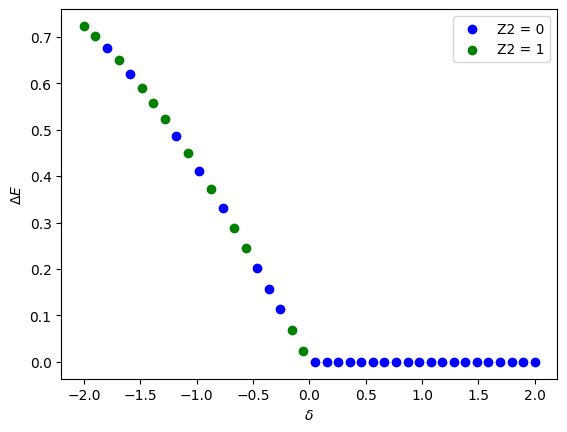

In [7]:
import matplotlib.pyplot as plt

# Convert to arrays for convenience
import numpy as np
results = np.array(results)

delta = results[:,0]
dE = results[:,1]
Z2 = results[:,2]

# Separate by Z2 value
mask0 = Z2 == 0
mask1 = Z2 == 1

plt.scatter(delta[mask0], dE[mask0], color='blue', label="Z2 = 0")
plt.scatter(delta[mask1], dE[mask1], color='green', label="Z2 = 1")

plt.xlabel(r'$\delta$')
plt.ylabel(r'$\Delta E$')
plt.legend()
plt.show()


Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[ 1.57079633 -0.90689968]: delta = 1.0
k=[0.         1.81379936]: delta = -1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!


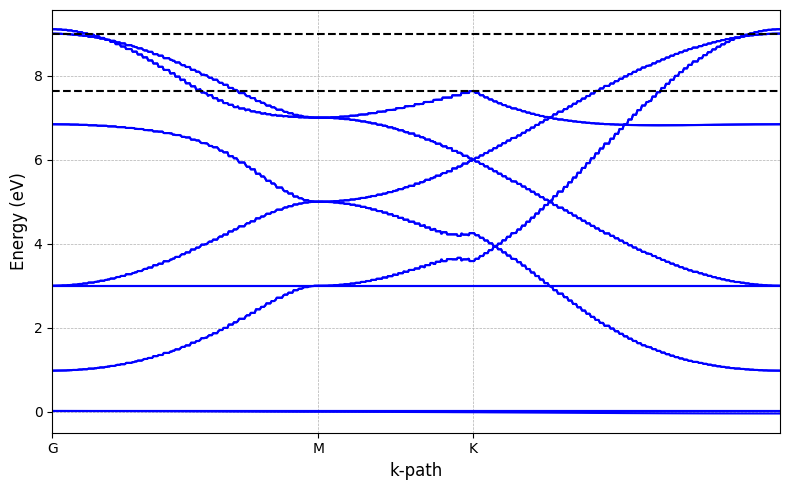

In [13]:
dE, E0, E1 = invariants.get_acceptor_band_gap(only_dE=False)
Z2 = invariants.Z2_invariant([-1, -2], print_deltas=True)
tb_bulk.plot_band_structure(g, bands = [i for i in range(9, 24)], energies=[E0, E1])